# Projeto Integrador III: Ciência de Dados
Tema: Análise de Furtos e Roubos na Grande Vitória (ES)

Grupo: Alexsander, Ester, Larissa Moraes, Lucas Rufino, Marcelo Mindas, Vanderson de Almeida.

Data: Maio de 2026

1. Introdução
Este notebook apresenta a Análise Preliminar (Entrega 2) das ocorrências criminais na Grande Vitória. Os dados foram extraídos do Portal da Secretaria de Segurança Pública (SESP-ES). O objetivo é identificar padrões para apoiar a tomada de decisão em segurança pública.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Configurações visuais
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("muted")

In [24]:
# Carregando os dados (Certifique-se que o arquivo está na mesma pasta)
dados = pd.read_csv("MICRODADOS_OCORRENCIAS.csv", sep=';', encoding='latin-1')

# Definindo os municípios da Grande Vitória para análise
municipios_gv = ['VITORIA', 'VILA VELHA', 'SERRA', 'CARIACICA', 'VIANA', 'GUARAPARI', 'FUNDAO']
dados_gv = dados[dados['Municipio'].str.strip().str.upper().isin(municipios_gv)].copy()

print(f"Total de registros na Grande Vitória: {len(dados_gv)}")
dados_gv.head()

Total de registros na Grande Vitória: 421831


,Data,Hora,TipoIncidente,TipoLocal,Municipio,Bairro
0,2026-04-30,09:30:00,FURTO: EM TRANSPORTE COLETIVO,TRANSP COLETIVO,VILA VELHA,CENTRO VILA VELHA
1,2026-04-30,17:00:00,ROUBO: A PESSOA EM VIA PÚBLICA,VIA PÚBLICA,VILA VELHA,GUARANHUNS
2,2026-04-30,02:00:00,FURTO: EM RESIDÊNCIA/CONDOMÍNIO,RESIDÊNCIA,VITORIA,JARDIM CAMBURI
3,2026-04-30,04:30:00,ESTELIONATO/FRAUDE,AMBIENTE WEB,VILA VELHA,CENTRO VILA VELHA
4,2026-04-30,07:42:00,FURTO: EM ESTABELECIMENTO COMERCIAL,COMÉRCIO,SERRA,PRAIA DA BALEIA


In [25]:
# 1. Padronização de textos
dados_gv['TipoIncidente'] = dados_gv['TipoIncidente'].str.strip().str.upper()

# 2. Filtro específico: Apenas Furtos e Roubos (Conforme o tema do projeto)
df_crimes = dados_gv[dados_gv['TipoIncidente'].str.contains('FURTO|ROUBO', na=False)].copy()

# 3. Tratamento da Hora (Transformando "Indeterminada" em Vazio/NaN)
df_crimes['Hora_Limpa'] = pd.to_datetime(df_crimes['Hora'], format='%H:%M:%S', errors='coerce').dt.hour

# 4. Criando DataFrame para análise temporal (removendo os vazios apenas aqui)
df_temporal = df_crimes.dropna(subset=['Hora_Limpa'])

print("Limpeza concluída com sucesso!")

Limpeza concluída com sucesso!


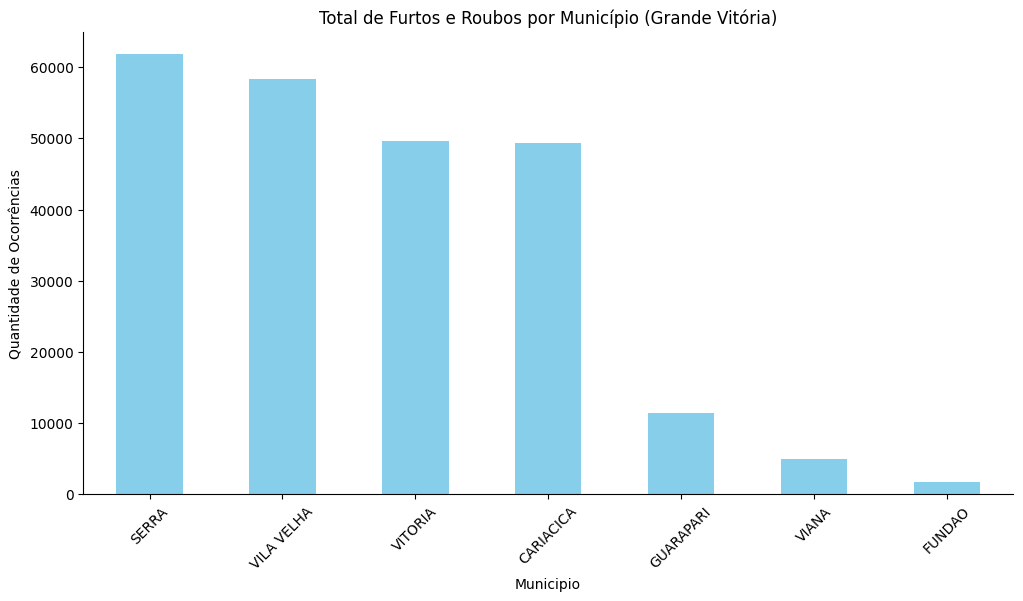

In [26]:
df_crimes['Municipio'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Total de Furtos e Roubos por Município (Grande Vitória)')
plt.ylabel('Quantidade de Ocorrências')
plt.xticks(rotation=45)
plt.show()

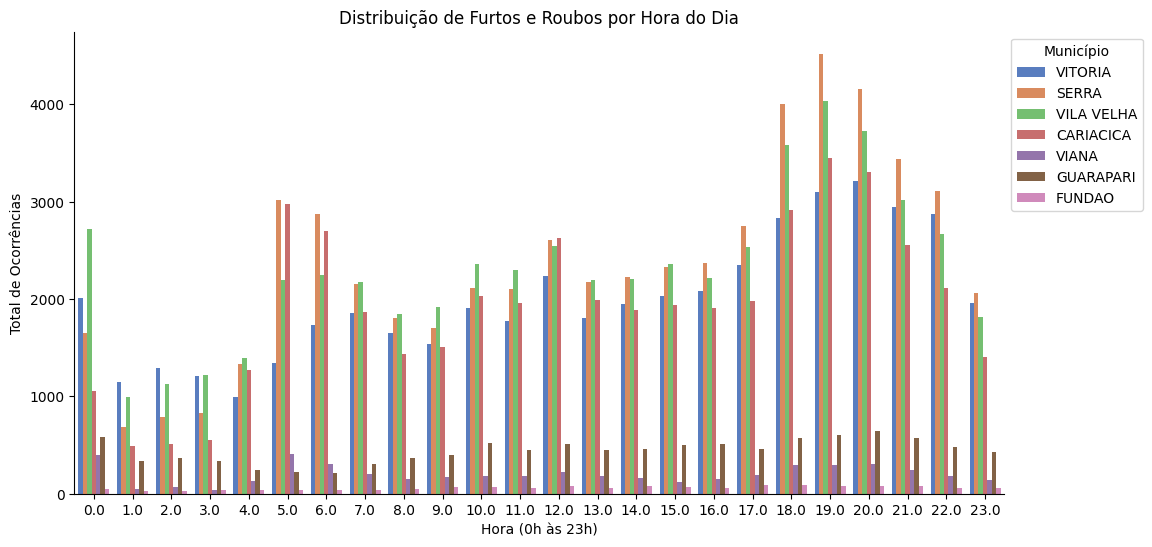

In [27]:
sns.countplot(data=df_temporal, x='Hora_Limpa', hue='Municipio') # Opcional: hue='Municipio' para ver por cidade
plt.title('Distribuição de Furtos e Roubos por Hora do Dia')
plt.xlabel('Hora (0h às 23h)')
plt.ylabel('Total de Ocorrências')
plt.legend(title='Município', bbox_to_anchor=(1, 1))
plt.show()

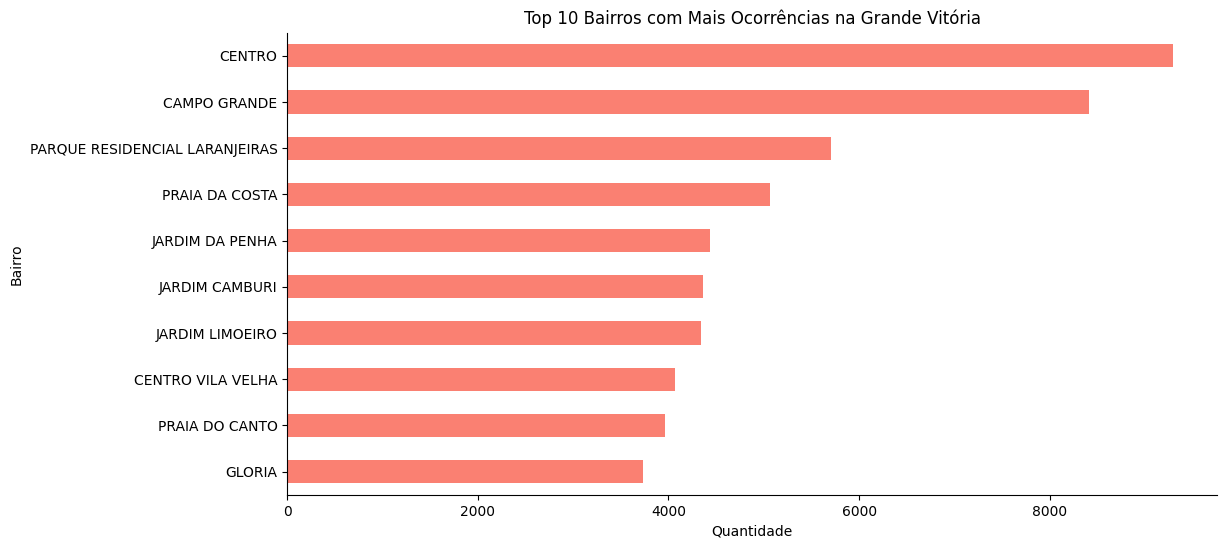

In [28]:
top_bairros = df_crimes['Bairro'].value_counts().nlargest(10)
top_bairros.plot(kind='barh', color='salmon').invert_yaxis()
plt.title('Top 10 Bairros com Mais Ocorrências na Grande Vitória')
plt.xlabel('Quantidade')
plt.show()